Setup

In [ ]:
%pip install --quiet qiskit qiskit-aer qiskit-ibm-runtime qiskit-ibmq-provider numpy scipy matplotlib pandas

In [2]:
%pip show qiskit-aer
import sys
print(sys.executable)

Name: qiskit-aer
Version: 0.17.2
Summary: Aer - High performance simulators for Qiskit
Home-page: https://github.com/Qiskit/qiskit-aer
Author: AER Development Team
Author-email: qiskit@us.ibm.com
License: Apache 2.0
Location: /usr/local/python/3.12.1/lib/python3.12/site-packages
Requires: numpy, psutil, python-dateutil, qiskit, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.
/home/codespace/.python/current/bin/python


In [3]:
import qiskit
from qiskit_aer import AerSimulator
from qiskit_aer.aerprovider import AerProvider
from qiskit_aer.jobs import AerJob
from qiskit_aer.aererror import AerError
from qiskit_aer.backends import *
from qiskit_aer import library
from qiskit_aer import quantum_info
from qiskit_aer import noise
from qiskit_aer import utils
from qiskit_aer.version import __version__

import numpy as np

In [4]:
IBM_QUANTUM_TOKEN = "r4IqbTTUxpez5jP4UIcfKOo-f8xki_93SKdFYCNUASB7"  # @param {type:"string"}

In [5]:
import os
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)


qiskit_runtime_service._discover_account:WARNING:2026-01-14 20:23:06,995: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-01-14 20:23:09,290: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [6]:
print(IBM_QUANTUM_TOKEN)

r4IqbTTUxpez5jP4UIcfKOo-f8xki_93SKdFYCNUASB7


Simulation with Noisy Channel

First, let us set up the noisy channel like the real hardware used in server 'ibm_fez'.

In [7]:

from qiskit_ibm_runtime import QiskitRuntimeService
# NoiseModel location varies by qiskit-aer version; try preferred locations
try:
    from qiskit_aer.noise import NoiseModel
except Exception:
    try:
        from qiskit.providers.aer.noise import NoiseModel
    except Exception:
        raise ImportError("NoiseModel import failed — install qiskit-aer or adjust import.")

service = QiskitRuntimeService(channel="ibm_quantum_platform", token=os.environ.get("IBM_QUANTUM_TOKEN"))
backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(backend)


qiskit_runtime_service.__init__:WARNING:2026-01-14 20:23:10,801: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-14 20:23:10,801: Using instance: open-instance, plan: open


Now, we should define the Clifford group. This group, Cliff_n, contains the gates, C, that will be tested with IRB.

In [8]:
from collections import deque
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from collections import deque

#To remove generated duplicates up to global phase, we shall normalise 
#the matrices and compare
def normalize_up_to_global_phase(U):
    #Divide by the phase of the first non-zero element
    idx = np.argmax(np.abs(U))
    phase = np.angle(U.flatten()[idx])

    return U*np.exp(-1j*phase)

#Generation of single qubit Clifford gates, having in mind the basis gates of the server used.
def generate_single_qubit_cliffords():
    generating_g = {'H': lambda qc: qc.h(0),
                    'S': lambda qc: qc.s(0)}
    seen_matrices = []
    circuits = []

    #queue is an auxiliary deque to store the circuits to be expanded and verify the matrices
    queue = deque([QuantumCircuit(1)]) #start with the identity

    while queue:
        qc = queue.popleft()
        U = Operator(qc).data
        U_norm = normalize_up_to_global_phase(U)

        if any(np.allclose(U_norm, M) for M in seen_matrices): #verify if they're the same
            continue
        seen_matrices.append(U_norm)
        circuits.append(qc)

        #Expand the circuit by applying the generating gates on the right (sequence growth)
        for g in generating_g.values():
            new_qc = qc.copy()
            g(new_qc)
            queue.append(new_qc)

    assert len(circuits) == 24, f"Expected 24 unique single-qubit Clifford circuits, found {len(circuits)}"
    
    return circuits #List of QuantumCircuits Objects (24)


In [9]:
#Testing if an operator was created
print(Operator(QuantumCircuit(1)).data)

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [10]:
# Generate Clifford circuits and compute inverse mapping
cliffords_list = generate_single_qubit_cliffords()

# Compute the inverse mapping: for each Clifford index i, find j such that C_i @ C_j ≈ Identity
cliffords_matrices = [normalize_up_to_global_phase(Operator(qc).data) for qc in cliffords_list]
I2 = np.eye(2, dtype=complex)

cliffords_inverses = {}
for i, U_i in enumerate(cliffords_matrices):
    for j, U_j in enumerate(cliffords_matrices):
        product = U_i @ U_j
        product_norm = normalize_up_to_global_phase(product)
        if np.allclose(product_norm, I2):
            cliffords_inverses[i] = j
            break

assert len(cliffords_inverses) == 24, f"Expected 24 inverses, found {len(cliffords_inverses)}"
print(f"Computed inverse mapping for all {len(cliffords_list)} Clifford gates.")
print(f"Example: Clifford 0 inverse is at index {cliffords_inverses[0]}")

Computed inverse mapping for all 24 Clifford gates.
Example: Clifford 0 inverse is at index 0


Creation of the sequence K

In [ ]:
def create_irb_sequence(
    clifford_circuits,
    clifford_inverses,
    cliffords_matrices,
    m,
    target_gate_circuit=None,
    fixed_clifford_idx=None,
    fixed_position=1,
    seed=None
):
    """
    Creates an IRB sequence K of given length m following the paper protocol, with option to set a specific Clifford at a chosen position.

    Structure: K = C_1, C_2, ..., C_m, C_(m+1)
    - C_1: random Clifford
    - C_2: fixed Clifford (if fixed_clifford_idx is provided)
    - C_3 to C_m: random Cliffords
    - C_(m+1): inverse Clifford that returns the qubit to |0⟩
    - Optionally, interleave a target gate after each Clifford

    Args:
        clifford_circuits: list of QuantumCircuit (24 Cliffords)
        clifford_inverses: dict mapping index -> inverse index
        cliffords_matrices: list of normalized unitary matrices for each Clifford
        m: sequence length (number of Cliffords)
        target_gate_circuit: QuantumCircuit of the gate to interleave (e.g., X gate), or None
        fixed_clifford_idx: index of Clifford to set at fixed_position (default None)
        fixed_position: position (1-based) to set fixed Clifford (default 1 for C_2)
        seed: optional random seed for reproducibility

    Returns:
        QuantumCircuit: full IRB sequence K with measurement
    """
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(clifford_circuits), size=m, replace=True)
    if fixed_clifford_idx is not None and 1 <= fixed_position <= m:
        indices[fixed_position - 1] = fixed_clifford_idx

    qc = QuantumCircuit(1, 1)
    for idx in indices:
        qc.compose(clifford_circuits[idx], inplace=True)
        if target_gate_circuit is not None:
            qc.compose(target_gate_circuit, inplace=True)

    # Compute C_(m+1): the Clifford that inverts the entire forward sequence
    U_fwd = Operator(qc).data
    U_fwd_norm = normalize_up_to_global_phase(U_fwd)
    m_plus_1_idx = None
    I = np.eye(2, dtype=complex)
    for j in range(len(cliffords_matrices)):
        product = normalize_up_to_global_phase(U_fwd_norm @ cliffords_matrices[j])
        if np.allclose(product, I):
            m_plus_1_idx = j
            break
    if m_plus_1_idx is None:
        raise RuntimeError("Could not find C_(m+1) inverse Clifford")
    qc.compose(clifford_circuits[m_plus_1_idx], inplace=True)
    qc.measure(0, 0)
    return qc


In [12]:
# Example: create IRB sequence with X gate interleaving
target_X = QuantumCircuit(1)
target_X.x(0)

# Create an IRB sequence of length m=4
m = 4
seed = 42
irb_seq = create_irb_sequence(
    clifford_circuits=cliffords_list,
    clifford_inverses=cliffords_inverses,
    cliffords_matrices=cliffords_matrices,
    m=m,
    target_gate_circuit=target_X,
    seed=seed
)

print(f"IRB sequence K (m={m}) created.")
print(f"Circuit depth (before transpilation): {irb_seq.depth()}")

IRB sequence K (m=4) created.
Circuit depth (before transpilation): 21


In [13]:
# Print the gates in the IRB sequence K
print(f"\nGates in IRB sequence K (m={m}):")
for i, instruction in enumerate(irb_seq.data):
    print(f"  {i}: {instruction}")



Gates in IRB sequence K (m=4):
  0: CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())
  1: CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())
  2: CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())
  3: CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())
  4: CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())
  5: CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())
  6: CircuitInstruction(operation=Instruction(name

In [14]:
%pip install --quiet matplotlib
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


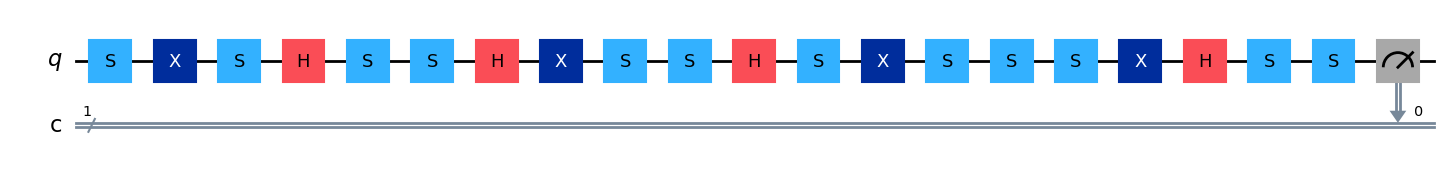

In [20]:
%matplotlib inline
fig = irb_seq.draw('mpl')
plt.show()


In [16]:
# Transpile to ibm_fez native gates for simulation
sim = AerSimulator()
irb_seq_transpiled = transpile(irb_seq, backend=backend)

print(f"Circuit depth (after transpilation to ibm_fez basis): {irb_seq_transpiled.depth()}")

# Run on simulator with noisy channel (emulating ibm_fez)
job = sim.run(irb_seq_transpiled, shots=2000, noise_model=noise_model)
result = job.result()
counts = result.get_counts()
survival_prob = counts.get('0', 0) / 2000

print(f"\nSimulation result:")
print(f"Counts: {counts}")
print(f"Survival probability P(|0 rangle): {survival_prob:.4f}")

Circuit depth (after transpilation to ibm_fez basis): 2

Simulation result:
Counts: {'1': 4, '0': 1996}
Survival probability P(|0 rangle): 0.9980


#Transpilation to use the server "ibm_fez"


In [ ]:
# IRB analysis: sequence fidelity, depolarizing parameter, and average error per gate
import scipy.optimize

# Parameters
sequence_lengths = [2, 4, 8, 16]
num_sequences = 20  # Number of random sequences per length
shots = 2000
seed_base = 12345

survival_probs = []

for m in sequence_lengths:
    probs = []
    for k in range(num_sequences):
        seed = seed_base + m * 100 + k
        irb_seq = create_irb_sequence(
            clifford_circuits=cliffords_list,
            clifford_inverses=cliffords_inverses,
            cliffords_matrices=cliffords_matrices,
            m=m,
            target_gate_circuit=target_X,
            seed=seed
        )
        irb_seq_transpiled = transpile(irb_seq, backend=backend)
        job = sim.run(irb_seq_transpiled, shots=shots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts()
        prob = counts.get('0', 0) / shots
        probs.append(prob)
    survival_probs.append(np.mean(probs))

# Fit F_seq(m) = A * p^m + B
m_vals = np.array(sequence_lengths)
F_seq = np.array(survival_probs)

def fit_func(m, A, p, B):
    return A * p**m + B

params, _ = scipy.optimize.curve_fit(fit_func, m_vals, F_seq, p0=[0.5, 0.95, 0.5], bounds=([0,0,0],[1,1,1]))
A, p, B = params

# Calculate average error per gate r
# For single qubit: d = 2
r = (2-1)/2 * (1-p)

print("Sequence lengths (m):", sequence_lengths)
print("Average survival probabilities:", F_seq)
print(f"Fit parameters: A={A:.4f}, p={p:.4f}, B={B:.4f}")
print(f"Depolarizing parameter p: {p:.4f}")
print(f"Average error per gate r: {r:.6f}")

# Plot F_seq(m)
plt.figure(figsize=(7,5))
plt.plot(m_vals, F_seq, 'o', label='Simulated data')
plt.plot(m_vals, fit_func(m_vals, *params), '-', label='Fit: $A p^m + B$')
plt.xlabel('Sequence length m')
plt.ylabel('Sequence fidelity $F_{seq}(m)$')
plt.title('Interleaved RB: Sequence Fidelity vs Length')
plt.legend()
plt.grid(True)
plt.show()